In [ ]:
# Details of Python implementation of Artificial Neural Network (ANN)
# Dr. G. Pang, August 2025

In [338]:
import numpy as np
import copy

In [339]:
def sigmoid(x):
    """Sigmoid activation function."""
    return 1.0 / (1.0 + np.exp(-x))

In [340]:
def bp_logsig_lin(inputs, outputs, num_hid, alpha, beta, err, max_stop):
    """
    Backpropagation Algorithm for an ANN with one hidden layer
    LOGSIG function is used in hidden layer; 
    LINEAR function is used in output layer.

    Args:
        inputs (numpy.ndarray): Input matrix of shape (samples, n).
        outputs (numpy.ndarray): Output matrix of shape (samples, q).
        num_hid (int): Number of hidden units (i.e., p).
        alpha (float): Learning rate between the output and hidden layer.
        beta (float): Learning rate between the input and hidden layer.
        err (float): Error for the stopping criterion.
        max_stop (int): Maximum number of iterations.

    Returns:
        tuple: (convergence, ave_err, max_err, result, v, w, thres_b, thres_c)
    """
    print("Demo on Backpropagation Algorithm by Dr. G. Pang")

    # Dimensions of input and output matrices
    num_examples, num_in = inputs.shape
    _, num_out = outputs.shape
    
    print('number of training samples = ', num_examples)
    print('number of input = ', num_in)
    print('number of output = ', num_out)

    if num_examples != outputs.shape[0]:
        raise ValueError("Number of input-output training examples not the same")

    # Initialize vectors for display
    convergence = np.zeros(max_stop)
    save_v = np.zeros(max_stop)
    save_w = np.zeros(max_stop)
    save_thres_b= np.zeros(max_stop)
    save_thres_c = np.zeros(max_stop)

    #-------------------------------------------
    # Initialize weights and thresholds randomly  NEW
    v = np.random.rand(num_in, num_hid) - 0.5*np.ones((num_in, num_hid))
    w = np.random.rand(num_hid, num_out) - 0.5*np.ones((num_hid, num_out))
    thres_b = np.random.rand(1, num_hid) - 0.5*np.ones((1, num_hid))
    thres_c = np.random.rand(1, num_out) - 0.5*np.ones((1, num_out))
#-------------------------------------------
    
    
    
    # Initialize variables
    iterations = 0
    max_err = 1000

    # Main training loop
    while max_err >= err and iterations < max_stop:
        iterations += 1

        for n in range(num_examples):
            # Forward pass
            a = inputs[n, :]
            ck = outputs[n, :]

            # Hidden layer outputs
            b = sigmoid(np.dot(a, v) + thres_b)

            # Output layer outputs
            c = np.dot(b, w) + thres_c

            # Compute errors at the output
            d = ck - c

            # Compute errors at the hidden layer
            e = b * (1 - b) * np.dot(d, w.T)

            # Update weights and thresholds
            w += alpha * np.outer(b, d)
            thres_c += alpha * d

            v += beta * np.outer(a, e)
            thres_b += beta * e

        # Recall phase
        save_err = np.zeros((num_examples, num_out))
        for n in range(num_examples):
            a = inputs[n, :]
            ck = outputs[n, :]

            # Hidden layer outputs
            b = sigmoid(np.dot(a, v) + thres_b)

            # Output layer outputs
            c = np.dot(b, w) + thres_c
            save_err[n, :] = np.abs(ck - c)

        # Calculate average and maximum errors
        ave_err = np.sum(save_err) / (num_examples * num_out)
        max_err = np.max(save_err)

        # print(f"Iteration: {iterations}, Average Error: {ave_err}, Max Error: {max_err}")
        convergence[iterations - 1] = ave_err
        save_v[iterations - 1]  = v[0,0] #save the first value of v
        save_w[iterations - 1]  = w[1,0] #save the second value of w
        save_thres_b[iterations - 1]  = thres_b[0,2] #save the third value of thres_b
        save_thres_c[iterations - 1]  = thres_c[0,0] #save the value of thres_c

    print("Stopping criterion has been reached!")
    #print("The results after training: inputs, desired outputs, NN outputs")

    # Final recall
    result = np.zeros((num_examples, num_out))
    for n in range(num_examples):
        a = inputs[n, :]
        b = sigmoid(np.dot(a, v) + thres_b)
        result[n, :] = np.dot(b, w) + thres_c

    return save_v,save_w,save_thres_b,save_thres_c, convergence, ave_err, max_err, result, v, w, thres_b, thres_c

In [341]:
# Part 1: 21 data points in two classes

P = np.linspace(-1,1,21)
print(P.shape)

T=np.array([-0.96, -0.577,  -0.0729,  0.377,  0.641,
            0.66 , 0.461 , 0.1336 , -0.201,  -0.434,
            -0.5 , -0.393,  -0.1647, 0.0988, 0.3072,
            0.396 ,0.3449 , 0.1816,  -0.0312,  -0.2189, -0.3201])

(21,)


In [342]:
# parameters
num_hid = 5
alpha = 0.3
beta = 0.3
err = 0.005 
max_stop = 3000 # max_num_iterations

inputs = copy.deepcopy(P)
outputs = copy.deepcopy(T)
inputs = inputs.reshape(21,1)
outputs = outputs.reshape(21,1)

In [343]:
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(
    inputs, outputs, num_hid, alpha, beta, err, max_stop)

Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Stopping criterion has been reached!


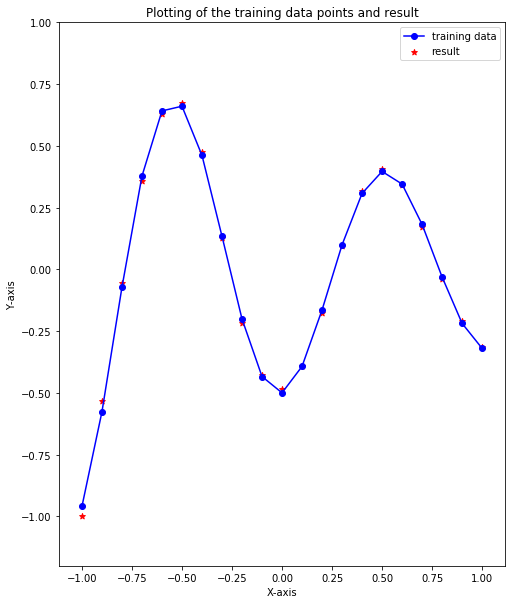

In [344]:
import matplotlib.pyplot as plt

show_result = result.reshape(21,1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs,result,label = 'result',marker='*',color = 'red')
plt.title('Plotting of the training data points and result')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-1.2,1)
plt.legend()
plt.show()

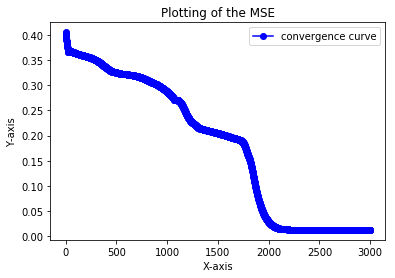

In [345]:
# To show the convergence curve, or 
# the variation of MSE during iterations

plt.plot(np.arange(0,len(convergence)),
         convergence,label = 'convergence curve',
         marker='o',color ='blue')

plt.title('Plotting of the MSE')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()


In [346]:
# What are the "results" from training ?
# 
print ('v = ', v)
print ('w = ', w)
print ('thres_b = ', thres_b)
print ('thres_c = ', thres_c)

v =  [[4.46695339 7.25605395 6.42174143 7.71395074 1.530536  ]]
w =  [[ 4.68649279]
 [-3.32585666]
 [-1.96941134]
 [ 1.55803538]
 [ 1.81608818]]
thres_b =  [[ 3.6407819   2.47286708 -4.53377926 -2.15338186 -1.3826692 ]]
thres_c =  [[-2.48928048]]


In [347]:
print(len(convergence))
print(save_v.shape)

3000
(3000,)


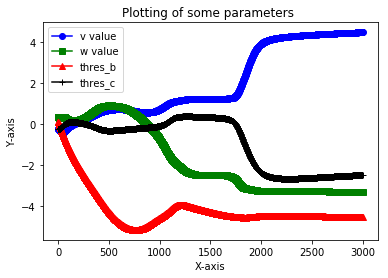

In [348]:
# To show the convergence curves 

plt.plot(np.arange(0,len(convergence)),
         save_v,label = 'v value',
         marker='o',color ='blue')

plt.plot(np.arange(0,len(convergence)),
         save_w,label = 'w value',
         marker='s',color ='green')

plt.plot(np.arange(0,len(convergence)),
         save_thres_b,label = 'thres_b',
         marker='^',color ='red')

plt.plot(np.arange(0,len(convergence)),
         save_thres_c,label = 'thres_c',
         marker='+',color ='black')

plt.title('Plotting of some parameters ')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()

In [350]:
# How many parameters are there ?
# 

print(v[0,0]) #first value of v
print(w[1,0]) #second value of w
print(thres_b[0,2]) #third value of thres_b
print(thres_c) #value of thres_c



4.466953392373784
-3.325856664709038
-4.533779256394141
[[-2.48928048]]


Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Stopping criterion has been reached!


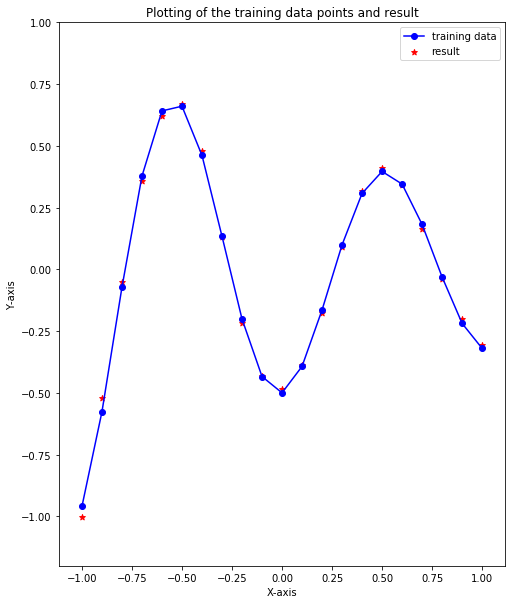

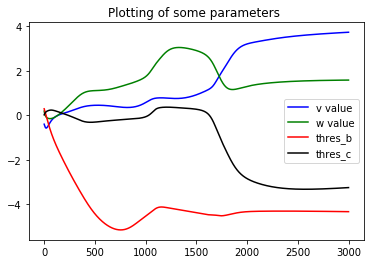

3.7362380469148007
1.5830386185734633
-4.33888160308893
[[-3.25518669]]


In [351]:
# parameters
num_hid = 5
alpha = 0.3
beta = 0.3
err = 0.005 
max_stop = 3000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(
    inputs, outputs, num_hid, alpha, beta, err, max_stop)

# To show the curve of convergence
show_result = result.reshape(21,1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs,result,label = 'result',marker='*',color = 'red')
plt.title('Plotting of the training data points and result')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-1.2,1)
plt.legend()
plt.show()

# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

# To display the chosen parameters
# 
print(v[0,0]) #first value of v
print(w[1,0]) #second value of w
print(thres_b[0,2]) #third value of thres_b
print(thres_c) #value of thres_c

In [352]:
# Note that the parameters obtained are different in each run


Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Stopping criterion has been reached!


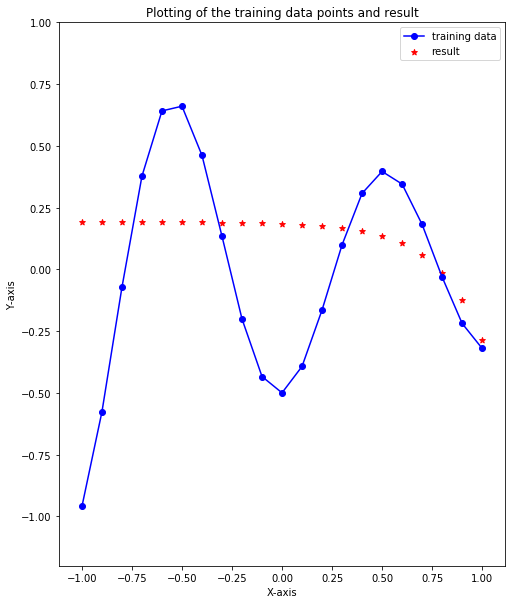

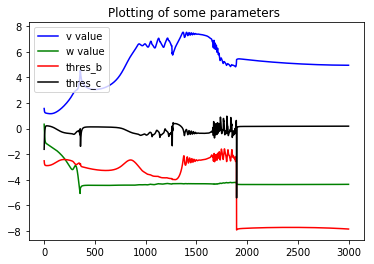

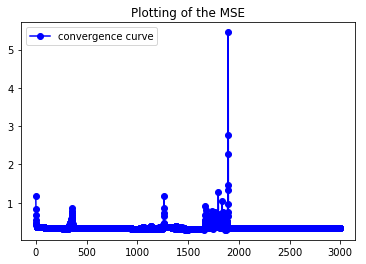

4.950512728945699
-4.354796429499366
-7.848094611500904
[[0.19051883]]


In [77]:
# parameters
num_hid = 5
alpha = 1.2
beta =1.2
err = 0.005 
max_stop = 3000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(
    inputs, outputs, num_hid, alpha, beta, err, max_stop)

# To show the curve of convergence
show_result = result.reshape(21,1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs,result,label = 'result',marker='*',color = 'red')
plt.title('Plotting of the training data points and result')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-1.2,1)
plt.legend()
plt.show()

# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         marker='o',color ='blue')

plt.title('Plotting of the convergence')
plt.legend()
plt.show()


# To display the chosen parameters
# 
print(v[0,0]) #first value of v
print(w[1,0]) #second value of w
print(thres_b[0,2]) #third value of thres_b
print(thres_c) #value of thres_c

In [ ]:
# The above shows instability. Next, we use smaller value of learning rate.

Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Stopping criterion has been reached!


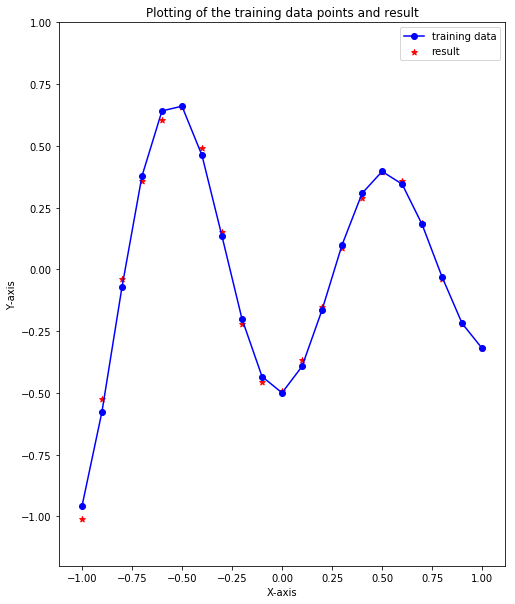

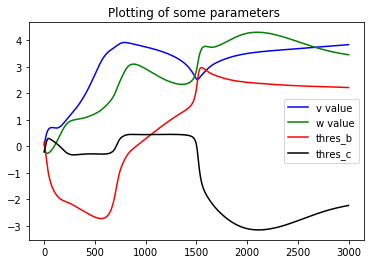

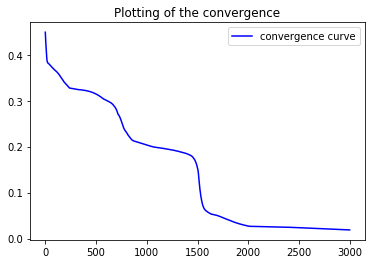

3.839542385090786
3.4590062503418206
2.222275050929136
[[-2.22503019]]


In [116]:
# parameters
num_hid = 5
alpha = 0.5
beta = 0.5
err = 0.005 
max_stop = 3000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(
    inputs, outputs, num_hid, alpha, beta, err, max_stop)

# To show the curve of convergence
show_result = result.reshape(21,1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs,result,label = 'result',marker='*',color = 'red')
plt.title('Plotting of the training data points and result')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-1.2,1)
plt.legend()
plt.show()

# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         color ='blue')

plt.title('Plotting of the convergence')
plt.legend()
plt.show()


# To display the chosen parameters
# 
print(v[0,0]) #first value of v
print(w[1,0]) #second value of w
print(thres_b[0,2]) #third value of thres_b
print(thres_c) #value of thres_c

In [111]:
# Next, we use learning rate of 0.3, but the y-values are scaled up by 8
P = np.linspace(-1,1,21)
print(P.shape)

T=np.array([-0.96, -0.577,  -0.0729,  0.377,  0.641,
            0.66 , 0.461 , 0.1336 , -0.201,  -0.434,
            -0.5 , -0.393,  -0.1647, 0.0988, 0.3072,
            0.396 ,0.3449 , 0.1816,  -0.0312,  -0.2189, -0.3201])*8
print(T)

inputs = copy.deepcopy(P)
outputs = copy.deepcopy(T)
inputs = inputs.reshape(21,1)
outputs = outputs.reshape(21,1)


(21,)
[-7.68   -4.616  -0.5832  3.016   5.128   5.28    3.688   1.0688 -1.608
 -3.472  -4.     -3.144  -1.3176  0.7904  2.4576  3.168   2.7592  1.4528
 -0.2496 -1.7512 -2.5608]


Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Stopping criterion has been reached!


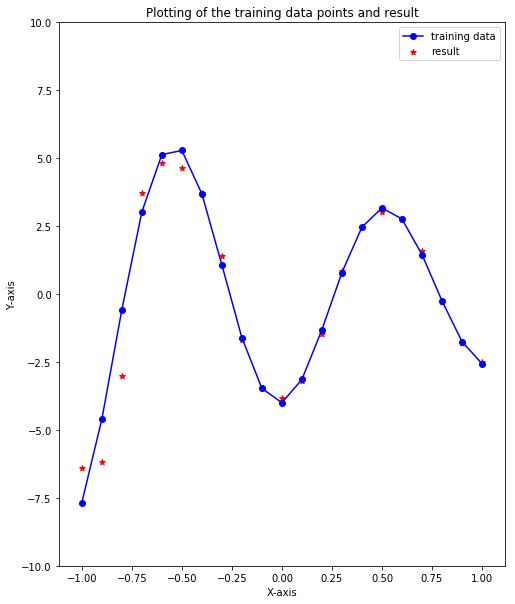

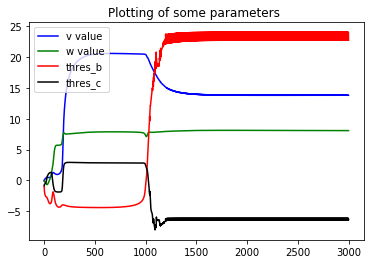

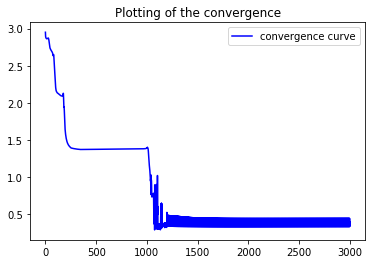

13.808293618200883
8.072400619271205
22.72526912484823
[[-6.41462089]]


In [113]:
# parameters
num_hid = 5
alpha = 0.3
beta = 0.3
err = 0.005 
max_stop = 3000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(inputs, outputs, num_hid, alpha, beta, err, max_stop)

# To show the curve of convergence
show_result = result.reshape(21,1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs,result,label = 'result',marker='*',color = 'red')
plt.title('Plotting of the training data points and result')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-10,10)
plt.legend()
plt.show()

# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         color ='blue')

plt.title('Plotting of the convergence')
plt.legend()
plt.show()


# To display the chosen parameters
# 
print(v[0,0]) #first value of v
print(w[1,0]) #second value of w
print(thres_b[0,2]) #third value of thres_b
print(thres_c) #value of thres_c

In [117]:
# The training algorithm shows sign of distress when the outputs 
# are not scaled well

In [147]:
# Next, we use learning rate of 0.3, but the y-values are scaled properly
# but with more hidden units
# When displaying the trained result, we use more x values.

P = np.linspace(-1,1,21)
print(P.shape)

T=np.array([-0.96, -0.577,  -0.0729,  0.377,  0.641,
            0.66 , 0.461 , 0.1336 , -0.201,  -0.434,
            -0.5 , -0.393,  -0.1647, 0.0988, 0.3072,
            0.396 ,0.3449 , 0.1816,  -0.0312,  -0.2189, -0.3201])
print(T)

inputs = copy.deepcopy(P)
outputs = copy.deepcopy(T)
inputs = inputs.reshape(21,1)
outputs = outputs.reshape(21,1)

(21,)
[-0.96   -0.577  -0.0729  0.377   0.641   0.66    0.461   0.1336 -0.201
 -0.434  -0.5    -0.393  -0.1647  0.0988  0.3072  0.396   0.3449  0.1816
 -0.0312 -0.2189 -0.3201]


In [148]:
P_more = np.linspace(-1,1,41)
print(P_more)
print(len(P_more))

[-1.   -0.95 -0.9  -0.85 -0.8  -0.75 -0.7  -0.65 -0.6  -0.55 -0.5  -0.45
 -0.4  -0.35 -0.3  -0.25 -0.2  -0.15 -0.1  -0.05  0.    0.05  0.1   0.15
  0.2   0.25  0.3   0.35  0.4   0.45  0.5   0.55  0.6   0.65  0.7   0.75
  0.8   0.85  0.9   0.95  1.  ]
41


Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Stopping criterion has been reached!


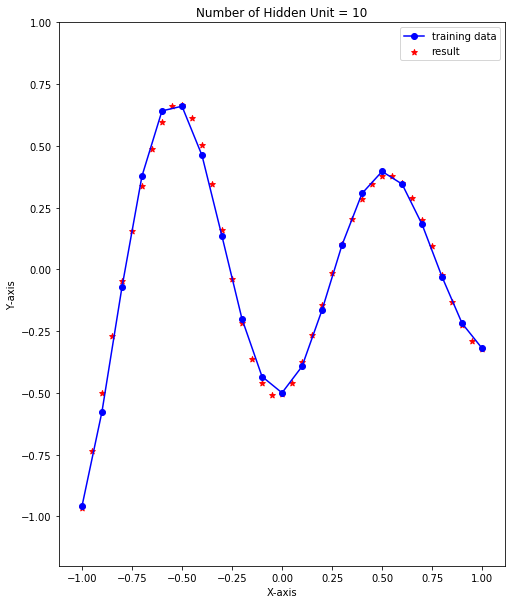

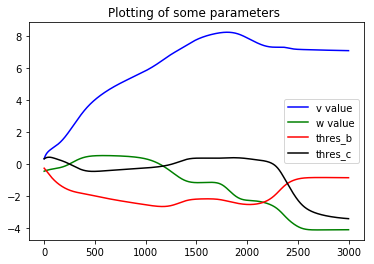

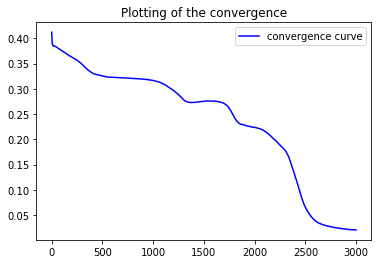

7.087846498973209
-4.122674699861495
-0.8667465308970946
[[-3.430709]]


In [166]:
# 10 hidden units
# parameters
num_hid = 10
alpha = 0.3
beta = 0.3
err = 0.005 
max_stop = 3000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(inputs, outputs, num_hid, alpha, beta, err, max_stop)

# To obtain more output points
inputs_more = copy.deepcopy(P_more)
inputs_more = P_more.reshape(len(P_more),1)

result_more = np.zeros((len(P_more),1))

for n in range(len(P_more)):
    a = inputs_more[n, :]
    b = sigmoid(np.dot(a, v) + thres_b)
    result_more[n, :] = np.dot(b, w) + thres_c

#show_result = result_more.reshape(len(P_more),1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs_more,result_more,label = 'result',marker='*',color = 'red')
plt.title('Number of Hidden Unit = 10')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-1.2,1)
plt.legend()
plt.show()

# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         color ='blue')
plt.title('Plotting of the convergence')
plt.legend()
plt.show()


# To display the chosen parameters
# 
print(v[0,0]) #first value of v
print(w[1,0]) #second value of w
print(thres_b[0,2]) #third value of thres_b
print(thres_c) #value of thres_c

Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Stopping criterion has been reached!


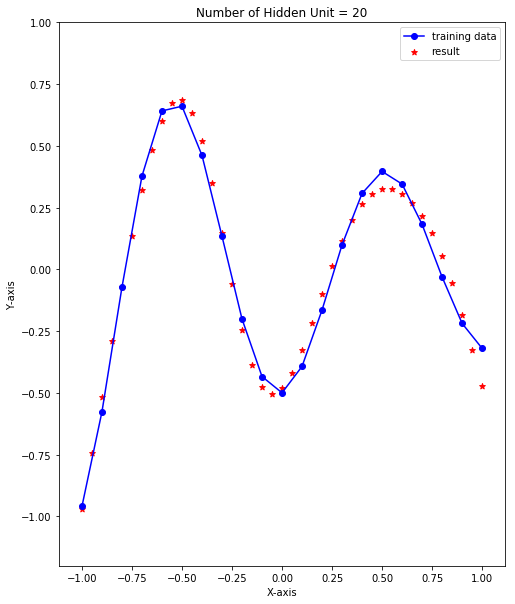

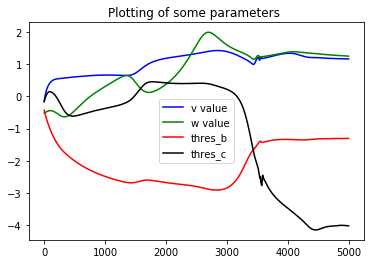

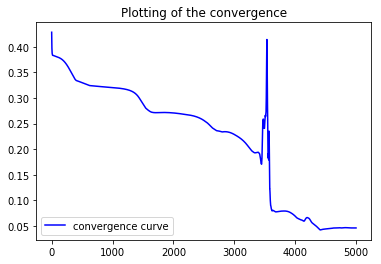

1.1628446336097489
1.250145199781304
-1.306814546071462
[[-4.02257563]]


In [182]:
# 20 hidden units
# parameters
num_hid = 20
alpha = 0.3
beta = 0.3
err = 0.005 
max_stop = 5000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(inputs, outputs, num_hid, alpha, beta, err, max_stop)

# To obtain more output points
inputs_more = copy.deepcopy(P_more)
inputs_more = P_more.reshape(len(P_more),1)

result_more = np.zeros((len(P_more),1))

for n in range(len(P_more)):
    a = inputs_more[n, :]
    b = sigmoid(np.dot(a, v) + thres_b)
    result_more[n, :] = np.dot(b, w) + thres_c

#show_result = result_more.reshape(len(P_more),1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs_more,result_more,label = 'result',marker='*',color = 'red')
plt.title('Number of Hidden Unit = 20')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-1.2,1)
plt.legend()
plt.show()

# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         color ='blue')
plt.title('Plotting of the convergence')
plt.legend()
plt.show()


# To display the chosen parameters
# 
print(v[0,0]) #first value of v
print(w[1,0]) #second value of w
print(thres_b[0,2]) #third value of thres_b
print(thres_c) #value of thres_c

Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Stopping criterion has been reached!


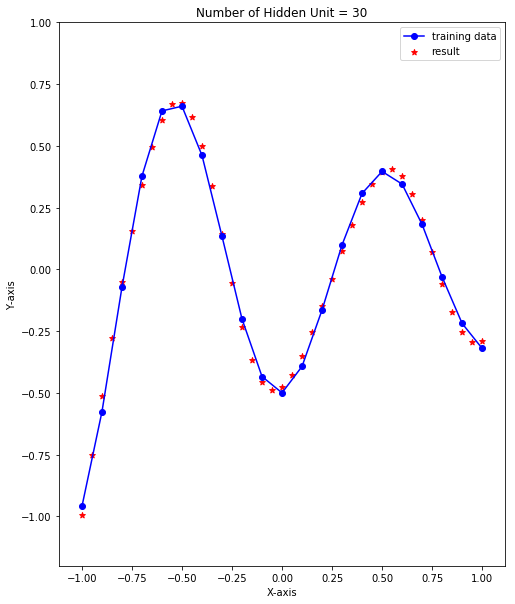

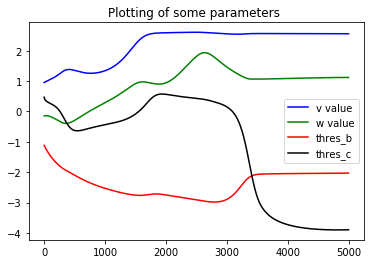

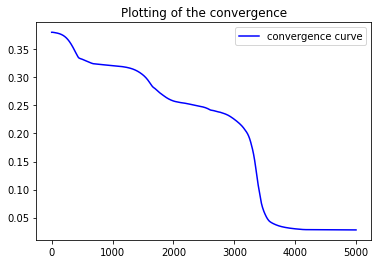

2.562382107067025
1.1223436476650872
-2.031769271434231
[[-3.8988539]]


In [186]:
# 30 hidden units
# parameters
num_hid = 30
alpha = 0.3
beta = 0.3
err = 0.005 
max_stop = 5000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(inputs, outputs, num_hid, alpha, beta, err, max_stop)

# To obtain more output points
inputs_more = copy.deepcopy(P_more)
inputs_more = P_more.reshape(len(P_more),1)

result_more = np.zeros((len(P_more),1))

for n in range(len(P_more)):
    a = inputs_more[n, :]
    b = sigmoid(np.dot(a, v) + thres_b)
    result_more[n, :] = np.dot(b, w) + thres_c

#show_result = result_more.reshape(len(P_more),1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs_more,result_more,label = 'result',marker='*',color = 'red')
plt.title('Number of Hidden Unit = 30')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-1.2,1)
plt.legend()
plt.show()

# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         color ='blue')
plt.title('Plotting of the convergence')
plt.legend()
plt.show()


# To display the chosen parameters
# 
print(v[0,0]) #first value of v
print(w[1,0]) #second value of w
print(thres_b[0,2]) #third value of thres_b
print(thres_c) #value of thres_c

Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Stopping criterion has been reached!


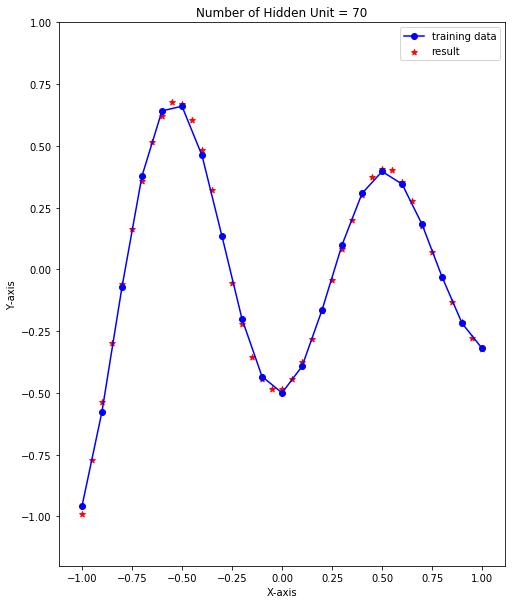

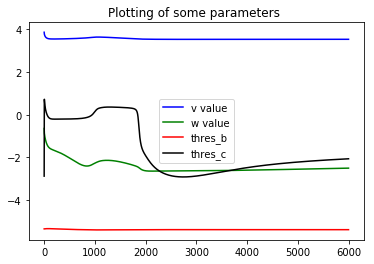

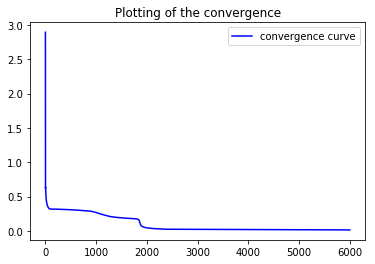

3.5390786254276736
-2.502880731044902
-5.388583962163873
[[-2.06408434]]


In [195]:
# 70 hidden units
# parameters
num_hid = 70
alpha = 0.3
beta = 0.3
err = 0.0005 
max_stop = 6000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(inputs, outputs, num_hid, alpha, beta, err, max_stop)

# To obtain more output points
inputs_more = copy.deepcopy(P_more)
inputs_more = P_more.reshape(len(P_more),1)

result_more = np.zeros((len(P_more),1))

for n in range(len(P_more)):
    a = inputs_more[n, :]
    b = sigmoid(np.dot(a, v) + thres_b)
    result_more[n, :] = np.dot(b, w) + thres_c

#show_result = result_more.reshape(len(P_more),1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs_more,result_more,label = 'result',marker='*',color = 'red')
plt.title('Number of Hidden Unit = 70')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-1.2,1)
plt.legend()
plt.show()

# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         color ='blue')
plt.title('Plotting of the convergence')
plt.legend()
plt.show()


# To display the chosen parameters
# 
print(v[0,0]) #first value of v
print(w[1,0]) #second value of w
print(thres_b[0,2]) #third value of thres_b
print(thres_c) #value of thres_c

Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Stopping criterion has been reached!


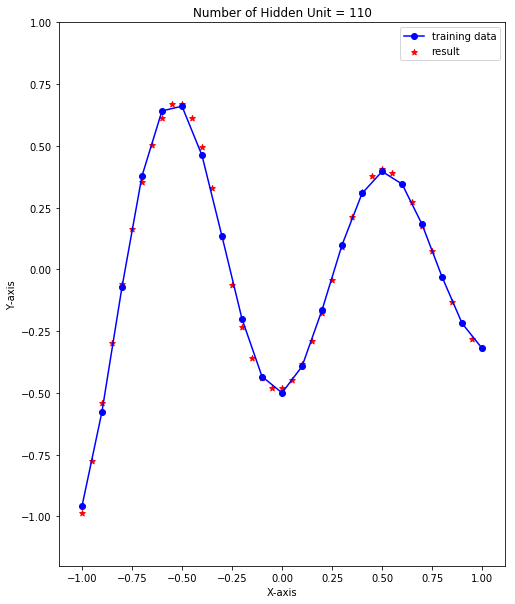

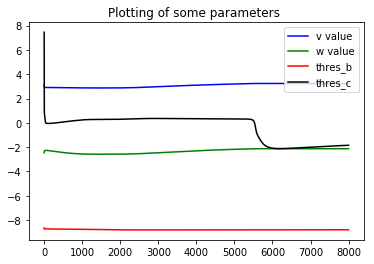

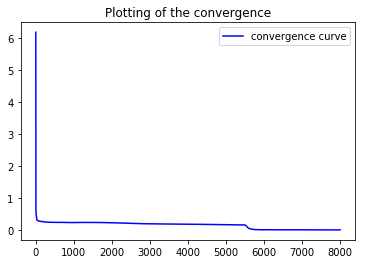

3.2345839350328514
-2.1285705678616593
-8.798424217748172
[[-1.84611334]]


In [420]:
# 110 hidden units
# parameters
num_hid = 110
alpha = 0.25
beta = 0.25
err = 0.0005 
max_stop = 8000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(inputs, outputs, num_hid, alpha, beta, err, max_stop)

# To obtain more output points
inputs_more = copy.deepcopy(P_more)
inputs_more = P_more.reshape(len(P_more),1)

result_more = np.zeros((len(P_more),1))

for n in range(len(P_more)):
    a = inputs_more[n, :]
    b = sigmoid(np.dot(a, v) + thres_b)
    result_more[n, :] = np.dot(b, w) + thres_c

#show_result = result_more.reshape(len(P_more),1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs_more,result_more,label = 'result',marker='*',color = 'red')
plt.title('Number of Hidden Unit = 110')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-1.2,1)
plt.legend()
plt.show()

# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         color ='blue')
plt.title('Plotting of the convergence')
plt.legend()
plt.show()


# To display the chosen parameters
# 
print(v[0,0]) #first value of v
print(w[1,0]) #second value of w
print(thres_b[0,2]) #third value of thres_b
print(thres_c) #value of thres_c

In [406]:
print(convergence.shape)
print(convergence[7999])

(8000,)
0.2468136173892274


In [ ]:
# NEW DEMO

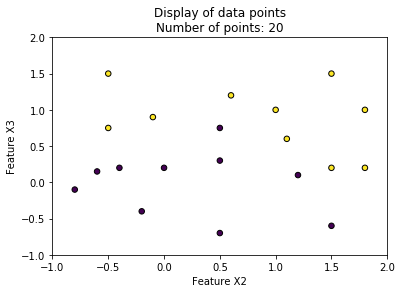

In [210]:
# Part 2: ANN with data points using one hidden layer
#----------------------------------------------------
# 2 inputs, one output (binary classification) 
# ANN demo: 20 training instances are defined
# These points are not linearly separable
#
tmpp= np.array([
    [1.0000  ,  1.0000   ,  1.0000],
    [1.1000  ,  0.6000  ,   1.0000],
    [1.5000  ,  0.2000  ,   1.0000],
    [-0.5000  , 0.7500  ,   1.0000],
    [-0.5000  , 1.5000  ,   1.0000],
    [-0.1000  , 0.9000  ,   1.0000],
    [ 0.6000  , 1.2    ,    1.0000],
    [1.5000   , 1.5     ,   1.0000],
    [1.8000  ,  1.0000   ,  1.0000],
    [1.8000  ,  0.2000  ,   1.0000],
    [-0.8000  , -0.1000  ,  0.0000],
    [-0.4000  , 0.2000  ,   0.0000],
    [-0.6000  , 0.1500  ,   0.0000],
    [-0.2000  , -0.4000 ,   0.0000],
    [1.2000  ,  0.1    ,    0.0000],
    [1.5    ,  -0.6     ,   0.0000],
    [0.5000  ,  0.7500  ,   0.0000],
    [0.5000  ,  0.3000 ,    0.0000],
    [0.5000  ,  -0.7000 ,   0.0000],
    [0.0000    , 0.2000 ,   0.0000],
   ])

X2=tmpp[:,0]
X3=tmpp[:,1]
desiredout=tmpp[:,2]

Num_datapoints = len(X2)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)
plt.title(f'Display of data points\n'
              f'Number of points: {Num_datapoints}')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')
plt.xlim(-1, 2)  # xmin=-1, xmax=2
plt.ylim(-1, 2)  
plt.show()

In [211]:
train_x=tmpp[:,0:2]
train_y=tmpp[:,2]
train_y = train_y.reshape((20,1))
print(train_x.shape)
print(train_y.shape)

(20, 2)
(20, 1)


In [212]:
# 15 hidden units
# parameters
num_hid = 15
alpha = 0.3
beta = 0.3
err = 0.001 
max_stop = 3000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(train_x, train_y, num_hid, alpha, beta, err, max_stop)

print(convergence.shape)

Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  20
number of input =  2
number of output =  1
Stopping criterion has been reached!
(3000,)


In [223]:
print('------------------------------------')
# Final recall
num_examples=20
num_out=1

result2 = np.zeros((num_examples, num_out))
for n in range(num_examples):
    a = train_x[n, :]
    b = sigmoid(np.dot(a, v) + thres_b)
    result2[n, :] = np.dot(b, w) + thres_c


------------------------------------
result2 =  [[ 0.59242245]
 [ 0.56460296]
 [ 0.53304635]
 [ 0.62656708]
 [ 0.63385506]
 [ 0.68562598]
 [ 0.62570172]
 [ 0.82292152]
 [ 0.80622605]
 [ 0.55025344]
 [-0.38257246]
 [-0.33266189]
 [-0.30662588]
 [-0.18193342]
 [ 0.44955674]
 [ 0.04864943]
 [ 0.30716309]
 [ 0.22920149]
 [-0.02585608]
 [-0.13703317]]
result =  [[ 0.59242245]
 [ 0.56460296]
 [ 0.53304635]
 [ 0.62656708]
 [ 0.63385506]
 [ 0.68562598]
 [ 0.62570172]
 [ 0.82292152]
 [ 0.80622605]
 [ 0.55025344]
 [-0.38257246]
 [-0.33266189]
 [-0.30662588]
 [-0.18193342]
 [ 0.44955674]
 [ 0.04864943]
 [ 0.30716309]
 [ 0.22920149]
 [-0.02585608]
 [-0.13703317]]


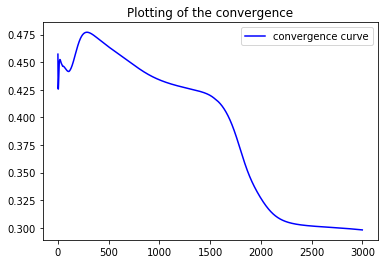

In [214]:
# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         color ='blue')
plt.title('Plotting of the convergence')
plt.legend()
plt.show()

In [225]:
xx, yy = np.meshgrid(np.linspace(-1, 2, 300),
                     np.linspace(-1, 2, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
print(grid.shape)


(90000, 2)


In [247]:
# Get output for the grid points to plot decision boundaries
percept = copy.deepcopy(xx)

for ixx in range(300):  
    for iyy in range(300):  
        a = np.array([xx[ixx,iyy], yy[ixx,iyy]] )
        b = sigmoid(np.dot(a, v) + thres_b)
        tmp_c = np.dot(b, w) + thres_c
        percept[ixx,iyy]  = np.array([tmp_c.item()])  #to convert to a simple python number
        

In [259]:
# Get output for the grid points to plot decision boundaries
percept_binary = copy.deepcopy(xx)

for ixx in range(300):  
    for iyy in range(300):  
        if percept[ixx,iyy] > 0.5:
            percept_binary[ixx,iyy] = np.array(1)
        else:
            percept_binary[ixx,iyy] = np.array(0)
        

In [260]:
print(percept_binary.shape)

(300, 300)


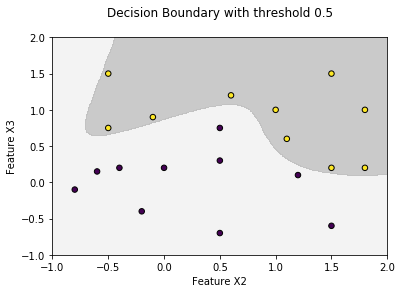

In [261]:
# Visualize the decision boundary
threshold_1 = 0.5

plt.contourf(xx, yy, percept_binary, levels=[0, threshold_1, 1], alpha=0.3, cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

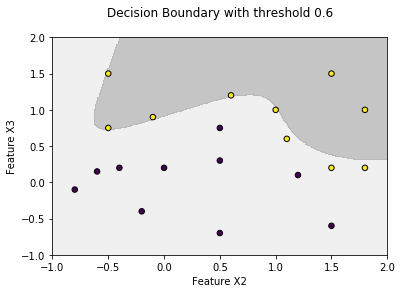

In [266]:
# Visualize the decision boundary
threshold_1 = 0.6

# Get output for the grid points to plot decision boundaries
percept_binary = copy.deepcopy(xx)

for ixx in range(300):  
    for iyy in range(300):  
        if percept[ixx,iyy] > threshold_1:
            percept_binary[ixx,iyy] = np.array(1)
        else:
            percept_binary[ixx,iyy] = np.array(0)

plt.contourf(xx, yy, percept_binary, levels=[0, threshold_1, 1], alpha=0.3, cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

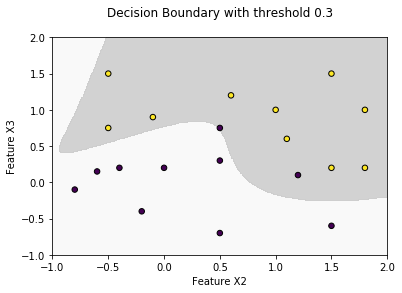

In [268]:
# Visualize the decision boundary
threshold_1 = 0.3

# Get output for the grid points to plot decision boundaries
percept_binary = copy.deepcopy(xx)

for ixx in range(300):  
    for iyy in range(300):  
        if percept[ixx,iyy] > threshold_1:
            percept_binary[ixx,iyy] = np.array(1)
        else:
            percept_binary[ixx,iyy] = np.array(0)

plt.contourf(xx, yy, percept_binary, levels=[0, threshold_1, 1], alpha=0.3, cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

In [318]:
# Part 3: Using ANN for color image segmentation
# 3-input, 2-output classification
# segment the image into 4 colors

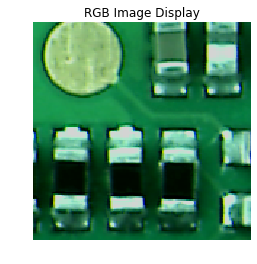

In [388]:
from PIL import Image

# Open the image file
image_name = "3503A.bmp" 
img = Image.open(image_name)
# Get image dimensions
width, height = img.size
# Ensure the image is in RGB mode 
img = img.convert("RGB")

# Display the image
plt.imshow(img)
plt.title("RGB Image Display")
plt.axis('off') # Hide axes 
plt.show()

In [389]:
img_new = Image.new('RGB',(width, height),color='black')
pixels_new = img_new.load()

In [390]:
# Define training instances (for the 4 colors)
tmpp = np.array([
    [5, 10, 5, 0, 0],       # black
    [0, 96, 50, 255, 0],    # green  
    [210, 210, 210, 0, 255], # white
    [0, 20, 0, 0, 0],       # black
    [194, 221, 209, 0, 255], # white
    [205, 215, 210, 0, 255], # white
    [230, 225, 235, 0, 255], # white
    [14, 106, 57, 255, 0],    # green 
    [62, 117, 78, 255, 0],    # green
    [26, 156, 81, 255, 0],    # green
    [0, 8, 0, 0, 0],          # black
    [193, 220, 112, 255, 255], # yellow
    [147, 192, 119, 255, 255], # yellow
    [0, 16, 7, 0, 0],          #black
    [177, 221, 156, 255, 255], #yellow
    [159, 204, 126, 255, 255]   #yellow
]) / 255.0


train_x.shape =  (16, 3)
train_y.shape =  (16, 2)
Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  16
number of input =  3
number of output =  2
Stopping criterion has been reached!
-------------------Finished training --------------
(7000,)


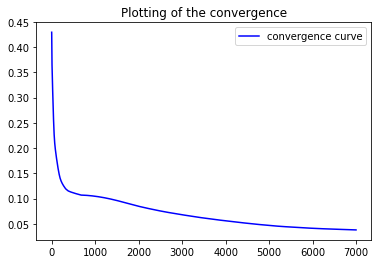

In [391]:
# Extract the inputs and outputs for training
train_x=tmpp[:,0:3]
train_y=tmpp[:,3:5]

print('train_x.shape = ', train_x.shape)
print('train_y.shape = ', train_y.shape)

# Start training with 15 hidden units
# parameters
num_hid = 15
alpha = 0.3
beta = 0.3
err = 0.001 
max_stop = 7000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(train_x, train_y, num_hid, alpha, beta, err, max_stop)

print('-------------------Finished training --------------')
print(convergence.shape)
# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         color ='blue')
plt.title('Plotting of the convergence')
plt.legend()
plt.show()

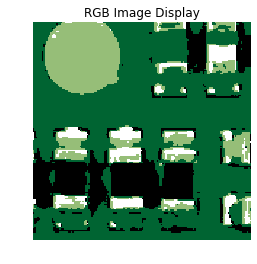

In [392]:
# To create a new image
black_v = [0, 0, 0]
white_v = [230, 230, 230]
green_v = [0, 100, 50]
yellow_v = [150, 190, 120]

# Iterate over each pixel in the image
width, height = img.size
threshold_d = 0.5

for x in range(height):
    for y in range(width):
        # Extract R, G, B values for the current pixel
        R, G, B = img.getpixel((x, y))
        
        a = np.array([R, G, B])/255 # scale down the input R,G,B, pixels
        b = sigmoid(np.dot(a, v) + thres_b)
        result_c = np.dot(b, w) + thres_c
        
        out1 = 1 if result_c[0,0] > threshold_d else 0
        out2 = 1 if result_c[0,1] > threshold_d else 0

        # Assign colors based on the outputs
        if out1 == 0 and out2 == 0:
            pixels_new[x,y] = (0,0,0)       # Black
        elif out1 == 0 and out2 == 1:
            pixels_new[x,y] = (255,255,255) # White
        elif out1 == 1 and out2 == 0:
            pixels_new[x,y] = (0,100,50)    # Green
        elif out1 == 1 and out2 == 1:
            pixels_new[x,y] = (150,190,120) # Yellow

# Display the image
plt.imshow(img_new)
plt.title("RGB Image Display")
plt.axis('off') # Hide axes for a cleaner image display
plt.show()


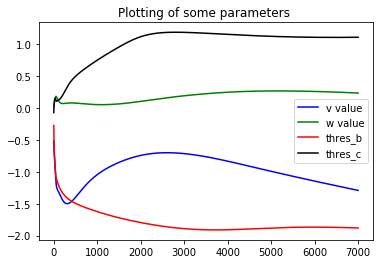

v = [[-1.29130534e+00 -1.13681530e+00 -1.00990339e+00 -2.55707657e+00
   1.19800304e+00  4.07923557e+00 -1.24051467e+00 -9.44371789e-01
  -5.46854004e-01 -1.61753971e+00 -4.73523730e-01 -1.54858825e+00
  -4.67424909e-01 -8.24750175e+00 -1.08950637e+00]
 [-1.02811649e+00 -8.91042268e-01 -7.94872910e-01 -7.63962453e+00
  -2.41850508e+00 -6.76063375e+00 -9.24264997e-01  1.10860227e+00
  -1.29052726e+00 -1.45732031e+00 -1.44072228e+00 -2.10821967e-03
  -1.41984066e+00 -4.16373514e+00  4.90560197e-01]
 [-2.04774189e+00 -1.05656150e-01 -1.11386498e+00 -4.68419915e+00
   4.97747887e-01  1.00980802e+01 -1.66024943e+00 -1.77451471e+00
  -2.01794575e+00 -8.14217616e-01 -1.81943683e+00 -2.66873153e-01
  -1.49255731e+00 -3.12938922e-01 -1.26006988e+00]]
w = [[ 1.09861651  0.18975284]
 [ 0.23300272  0.92969298]
 [ 0.54096557  0.6563409 ]
 [-1.94332654 -0.22179508]
 [-0.0613068  -0.86971819]
 [-1.21803629  0.08209237]
 [ 0.98652133  0.42137567]
 [-0.27391555  0.78110192]
 [ 0.90040379 -0.21560444]
 

In [393]:
# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

print('v =' , v)
print('w =', w)
print('thres_b =', thres_b)
print('thres_c =',thres_c)

1284 1081


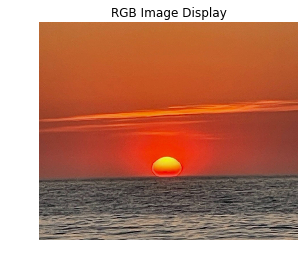

In [395]:
from PIL import Image

# Open the image file
image_name = "sunset.jpg" 
img = Image.open(image_name)
# Get image dimensions
width, height = img.size
# Ensure the image is in RGB mode 
img = img.convert("RGB")
print(width, height)
# Display the image
plt.imshow(img)
plt.title("RGB Image Display")
plt.axis('off') # Hide axes 
plt.show()

In [396]:
img_new2 = Image.new('RGB',(width, height),color='black')
pixels_new2 = img_new2.load()

# Define training instances (for the 8 colors)
tmpp = np.array([
    [199,91,39, 0, 0, 0],       # orange1
    [191,95,45, 0, 0 ,0],      #   
    [188, 87, 43, 0, 0, 0],   # 
    [239,129, 42,0,0, 255],   # light_orange
    [241,133, 34,0,0, 255],   # 
    [238,125, 57,0,0, 255],   # 
    [143,62,45,0,255,0],      # dark_orange
    [139,67,55,0,255,0],    # 
    [148,62,49,0,255,0],    # 
    [240,48,0,0,255,255],    # orange2
    [242,52,2,0,255,255],          # 
    [241,49,2,0,255,255],    # 
    [240,235,4,255,0,0],     # yellow
    [241,206,40,255,0,0],          #
    [241,210,32,255,0,0],       #
        [243,28,0,255,0,255],       # orange3
        [240,9,1,255,0,255],       # 
        [236,12,0,255,0,255],       # 
        [72,49,43,255,255,0],       # grey1
        [75,54,51,255,255,0],       #
        [60,50,48,255,255,0],       #
        [51,33,33,255,255,255],       # dark_grey
        [70,64,64,255,255,255],       #
        [51,51,49,255, 255,255]      # 
]) / 255.0


train_x.shape =  (24, 3)
train_y.shape =  (24, 3)
Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  24
number of input =  3
number of output =  3
Stopping criterion has been reached!
-------------------Finished training --------------
(7000,)


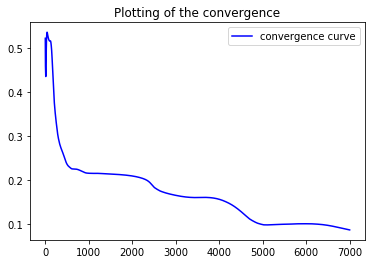

In [403]:
# Extract the inputs and outputs for training
train_x=tmpp[:,0:3]
train_y=tmpp[:,3:6]

print('train_x.shape = ', train_x.shape)
print('train_y.shape = ', train_y.shape)

# Start training with 15 hidden units
# parameters
num_hid = 15
alpha = 0.3
beta = 0.3
err = 0.001 
max_stop = 7000 # max_num_iterations

# To carry out the training
save_v,save_w,save_thres_b,save_thres_c,convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(train_x, train_y, num_hid, alpha, beta, err, max_stop)

print('-------------------Finished training --------------')
print(convergence.shape)
# To show the convergence curve
plt.plot(np.arange(0,len(convergence)),convergence,label = 'convergence curve',
         color ='blue')
plt.title('Plotting of the convergence')
plt.legend()
plt.show()

width =  1284
height =  1081


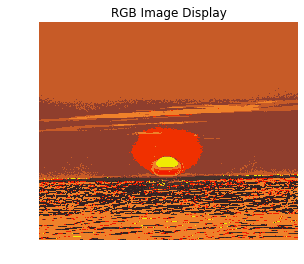

In [404]:
# To create a new image
orange1_v = [199,91,39]
light_orange_v = [239,129,42]
dark_orange_v = [143,62,45]
orange2_v = [240,48,0]
yellow_v = [240,235,4]
orange3_v = [243,28,0]
grey1_v = [72,49,43]
dark_grey_v = [51,33,33]

# Iterate over each pixel in the image
width, height = img_new2.size
threshold_d = 0.6

print('width = ', width)
print('height = ', height)

for x in range(width):
    for y in range(height):
        # Extract R, G, B values for the current pixel of given image
        R, G, B = img.getpixel((x, y))
        
        a = np.array([R, G, B])/255  #Needs to scale down the input R,G,B to [0,1]
        b = sigmoid(np.dot(a, v) + thres_b)
        result_c = np.dot(b, w) + thres_c
        
        out1 = 1 if result_c[0,0] > threshold_d else 0
        out2 = 1 if result_c[0,1] > threshold_d else 0
        out3 = 1 if result_c[0,2] > threshold_d else 0

        # Assign colors based on the outputs
        if out1 == 0 and out2 == 0 and out3 == 0:
            pixels_new2[x,y] = (199,91,39)       # orange1
        elif out1 == 0 and out2 == 0 and out3 == 1:
            pixels_new2[x,y] = (239,129,42)    # light_orange
        elif out1 == 0 and out2 == 1 and out3 == 0:
            pixels_new2[x,y] = (143,62,45)    # dark_orange
        elif out1 == 0 and out2 == 1 and out3 == 1:
            pixels_new2[x,y] = (240,48,0)     # orange2
        elif out1 == 1 and out2 == 0 and out3 == 0:
            pixels_new2[x,y] = (240,235,4)     # yellow
        elif out1 == 1 and out2 == 0 and out3 == 1:
            pixels_new2[x,y] = (243,28,0)     # orange3
        elif out1 == 1 and out2 == 1 and out3 == 0:
            pixels_new2[x,y] = (72,49,43)     # grey1
        elif out1 == 1 and out2 == 1 and out3 == 1:
            pixels_new2[x,y] = (51,33,33)     # dark_grey

# Display the image
plt.imshow(img_new2)
plt.title("RGB Image Display")
plt.axis('off') # Hide axes for a cleaner image display
plt.show()


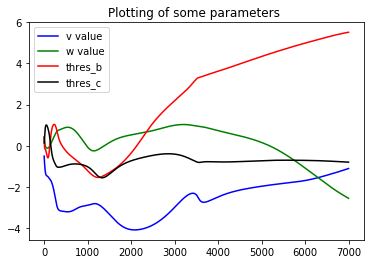

v = [[ -1.1051633  -15.99991684  -2.02511895  -0.81109495  -1.6655255
   -1.14133857   5.59743557  -1.45461633  -0.54412492  -1.87627862
   -3.37933234  -1.97596865  -0.86616727  10.44032264  -7.24797129]
 [ -9.7951454    4.92126142 -25.91332098  -3.53763581   1.03326376
   -1.77573884 -15.63152968  -1.25375964  -2.51952873  -3.29337738
    2.86600931  -0.95394414  -1.95397656   7.16018777  12.62972732]
 [  4.62225789  19.87063864  -9.02543265  -0.8447835   -0.68200015
    0.45437038  -4.68871675   0.75082457  -1.10653066   4.50960147
    3.67379699   1.33160158  -0.37707039  -8.83595292  -6.29209783]]
w = [[-1.89487814e+00  5.61168654e+00  7.09703190e-01]
 [-2.54645790e+00 -3.55163893e+00  1.06544183e+01]
 [ 1.94096650e-01 -2.49572304e+00  3.40081082e+00]
 [-2.66931217e-01  2.87159935e+00 -2.63802777e-01]
 [ 8.77789382e-01  4.53409257e-01 -1.07972137e+00]
 [ 4.66765976e-01  1.98626279e+00 -5.28869597e-01]
 [ 2.06205449e+00  5.03437484e-01 -3.67070985e+00]
 [ 8.22505007e-01  1.61835897

In [401]:
# To show the curves of four parameters
plt.plot(np.arange(0,len(convergence)),save_v,label = 'v value',color ='blue')

plt.plot(np.arange(0,len(convergence)),save_w,label = 'w value',color ='green')

plt.plot(np.arange(0,len(convergence)),save_thres_b,label = 'thres_b',color ='red')

plt.plot(np.arange(0,len(convergence)),save_thres_c,label = 'thres_c',color ='black')

plt.title('Plotting of some parameters ')
plt.legend()
plt.show()

print('v =' , v)
print('w =', w)
print('thres_b =', thres_b)
print('thres_c =',thres_c)